# Experiment 3: Load Ratio × Temperature Phase Diagram
This notebook maps the joint effect of memory load ratio K/d and inverse temperature beta on pattern retrieval. We fix d=64, sweep K/d from 0.05 to 2.0, and sweep beta on a log-spaced grid from 0.5 to 100.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Construct a phase diagram:__ Map the attention concentration in the load-ratio–inverse-temperature plane to identify retrieval and disordered regions
> * __Interpret the phase boundary:__ Identify the smooth boundary separating the high-concentration (retrieval) region from the low-concentration (diffuse) region
> * __Understand load ratio effects:__ Explain how increasing the load ratio (more stored patterns per dimension) shifts the retrieval threshold to higher inverse temperature

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [8]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

___
## Generate Additional Load Ratios (if needed)
Fill in 8 extra ratios so the sweep has 15 points total. Saved to disk for reproducibility (seeds 33101–33108). Skips any that already exist.


In [9]:
# Generate extra ratios and save to disk (same pattern as DataGeneration notebook)
d_exp3 = 64
extra_ratios = [0.05, 0.15, 0.35, 0.75, 1.5, 3.0, 6.0, 10.0]
ratio_basedir = joinpath(_PATH_TO_DATA, "exp3_loadratio")

for (i, ratio) in enumerate(extra_ratios)
    K_i = max(1, round(Int, ratio * d_exp3))
    seed_i = 33100 + i
    ratio_dir = joinpath(ratio_basedir, "ratio_$(ratio)")
    
    if isdir(ratio_dir)
        println("  K/d = $ratio already exists, skipping")
        continue
    end
    
    result = datagenerate(d_exp3, K_i, 5; path=ratio_dir, seed=seed_i)
    println("  K/d = $ratio → K = $K_i, saved (seed=$seed_i)")
end
println("\nDone — all extra ratios on disk.")


  K/d = 0.05 already exists, skipping
  K/d = 0.15 already exists, skipping
  K/d = 0.35 already exists, skipping
  K/d = 0.75 already exists, skipping
  K/d = 1.5 already exists, skipping
  K/d = 3.0 already exists, skipping
  K/d = 6.0 already exists, skipping
  K/d = 10.0 already exists, skipping

Done — all extra ratios on disk.


___
## Load All Ratios from Disk
Auto-discover every `ratio_*` directory — picks up both original and extra ratios.


In [10]:
# Discover all ratio directories on disk (original 7 + 8 extras = 15)
d_exp3 = 64
ratio_basedir = joinpath(_PATH_TO_DATA, "exp3_loadratio")

# Parse ratio from directory name "ratio_X.XX"
all_ratio_dirs = filter(d -> startswith(d, "ratio_"), readdir(ratio_basedir))
ratios = sort([parse(Float64, split(d, "_")[2]) for d in all_ratio_dirs])

# Load all datasets
exp3_datasets = Dict{Float64, Dict{String, Any}}()
for ratio in ratios
    data = JLD2.load(joinpath(ratio_basedir, "ratio_$(ratio)", "data.jld2"), "result")
    exp3_datasets[ratio] = data
    K_i = data["K"]
    println("K/d = $(lpad(ratio, 5)) → K = $(lpad(K_i, 3)), d = $(data["d"]), N = $(data["N"]) datasets")
end
println("\nLoaded $(length(ratios)) load ratios")


K/d =  0.05 → K =   3, d = 64, N = 5 datasets
K/d =   0.1 → K =   6, d = 64, N = 5 datasets
K/d =  0.15 → K =  10, d = 64, N = 5 datasets
K/d =  0.25 → K =  16, d = 64, N = 5 datasets
K/d =  0.35 → K =  22, d = 64, N = 5 datasets
K/d =   0.5 → K =  32, d = 64, N = 5 datasets
K/d =  0.75 → K =  48, d = 64, N = 5 datasets
K/d =   1.0 → K =  64, d = 64, N = 5 datasets
K/d =   1.5 → K =  96, d = 64, N = 5 datasets
K/d =   2.0 → K = 128, d = 64, N = 5 datasets
K/d =   3.0 → K = 192, d = 64, N = 5 datasets
K/d =   4.0 → K = 256, d = 64, N = 5 datasets
K/d =   6.0 → K = 384, d = 64, N = 5 datasets
K/d =   8.0 → K = 512, d = 64, N = 5 datasets
K/d =  10.0 → K = 640, d = 64, N = 5 datasets

Loaded 15 load ratios


___
## Configure the Sampler
Fine grid of $\beta$ values (log-spaced) for the heatmap. Step size $\alpha$ and chain length are shared.


In [11]:
# Sampler configuration
n_β = 20
βs = 10 .^ range(log10(0.5), log10(100.0); length=n_β)  # 20 log-spaced values from 0.5 to 100
α  = 0.01         # step size
T  = 10000        # iterations per chain
T_burnin = 2000   # burn-in

# Filter ratios to K/d ≤ 2.0 for the phase diagram
x_max = 2.0
ratios_plot = sort(filter(r -> r <= x_max, ratios))
K_plot = [max(1, round(Int, r * d_exp3)) for r in ratios_plot]

println("β grid: $(n_β) values from $(round(βs[1]; digits=2)) to $(round(βs[end]; digits=1))")
println("K/d grid: $(length(ratios_plot)) values from $(ratios_plot[1]) to $(ratios_plot[end])")
println("Total conditions: $(n_β * length(ratios_plot)) × 5 datasets = $(n_β * length(ratios_plot) * 5) runs")
println("α = $α, T = $T, burn-in = $T_burnin")


β grid: 20 values from 0.5 to 100.0
K/d grid: 10 values from 0.05 to 2.0
Total conditions: 200 × 5 datasets = 1000 runs
α = 0.01, T = 10000, burn-in = 2000


___
## Compute the Phase Diagram
For each $(\beta, K/d)$ pair, run Algorithm 1 on 5 datasets and average the attention concentration.


In [12]:
# Concentration matrix: rows = β (low→high), cols = K/d (low→high)
C_matrix = zeros(length(βs), length(ratios_plot))

for (bi, β) in enumerate(βs)
    println("── β = $(round(β; digits=2)) ($(bi)/$(length(βs))) ──")
    
    for (ri, ratio) in enumerate(ratios_plot)
        data = exp3_datasets[ratio]
        datasets = data["datasets"]
        K_i = data["K"]
        
        C_vals = Float64[]
        
        for (j, Xj) in enumerate(datasets)
            Random.seed!(3000 + j)
            ξ₀ = randn(d_exp3)
            ξ₀ ./= norm(ξ₀)
            
            (t, Ξ) = sample(Xj, ξ₀, T; β=β, α=α, seed=4000 + j)
            
            ents = Float64[]
            for i in (T_burnin + 2):(T + 1)
                ξ_t = Ξ[i, :]
                push!(ents, attention_entropy(ξ_t, Xj, β))
            end
            push!(C_vals, 1.0 - mean(ents) / log(K_i))
        end
        
        C_matrix[bi, ri] = mean(C_vals)
    end
end
println("\nDone — C_matrix is $(size(C_matrix, 1)) × $(size(C_matrix, 2))")
println("C range: [$(round(minimum(C_matrix); digits=4)), $(round(maximum(C_matrix); digits=4))]")


── β = 0.5 (1/20) ──
── β = 0.66 (2/20) ──
── β = 0.87 (3/20) ──
── β = 1.15 (4/20) ──
── β = 1.53 (5/20) ──
── β = 2.02 (6/20) ──
── β = 2.66 (7/20) ──
── β = 3.52 (8/20) ──
── β = 4.65 (9/20) ──
── β = 6.15 (10/20) ──
── β = 8.13 (11/20) ──
── β = 10.74 (12/20) ──
── β = 14.2 (13/20) ──
── β = 18.77 (14/20) ──
── β = 24.8 (15/20) ──
── β = 32.78 (16/20) ──
── β = 43.32 (17/20) ──
── β = 57.25 (18/20) ──
── β = 75.66 (19/20) ──
── β = 100.0 (20/20) ──

Done — C_matrix is 20 × 10
C range: [0.0515, 1.0]


___
## Exploratory Plot: Phase Diagram Heatmap
Quick diagnostic — concentration C on a (K/d, β) grid.

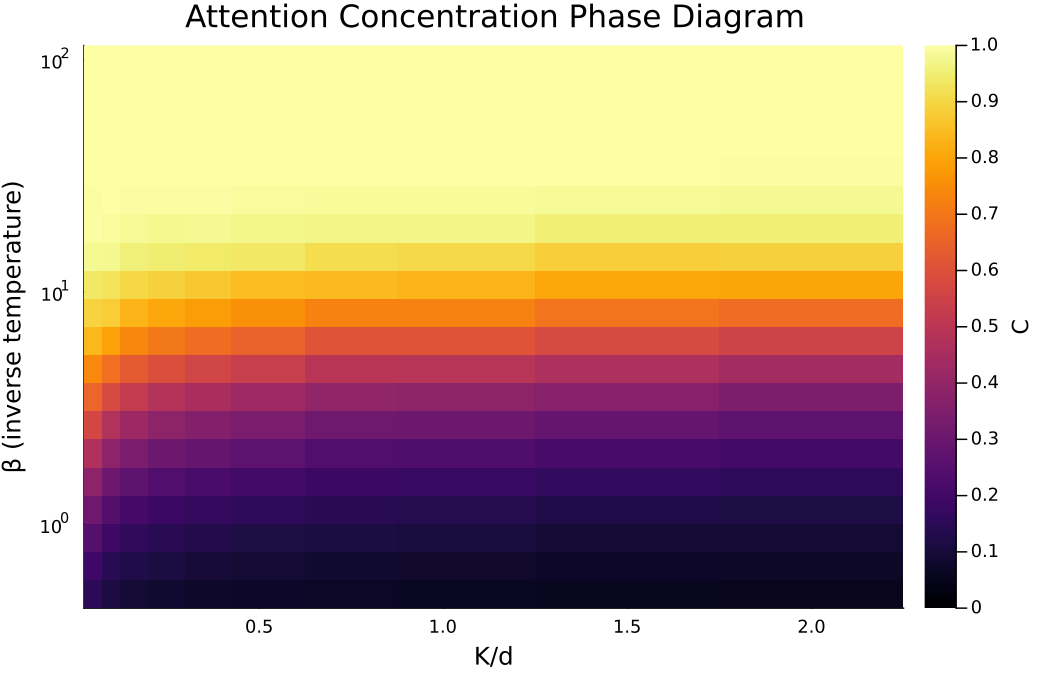

In [13]:
# Quick diagnostic heatmap
p_diag = heatmap(ratios_plot, βs, C_matrix;
    xlabel = "K/d",
    ylabel = "β (inverse temperature)",
    title  = "Attention Concentration Phase Diagram",
    colorbar_title = "C",
    color  = :inferno,
    clims  = (0, 1),
    yscale = :log10,
    size   = (700, 450),
    dpi    = 150
)
display(p_diag)

___
## Paper Figure: Phase Diagram Heatmap
Publication-quality heatmap: K/d on x-axis, β (log-scale) on y-axis, color = attention concentration C.

Saved: figs/Fig_experiment-3-load-ratio.pdf


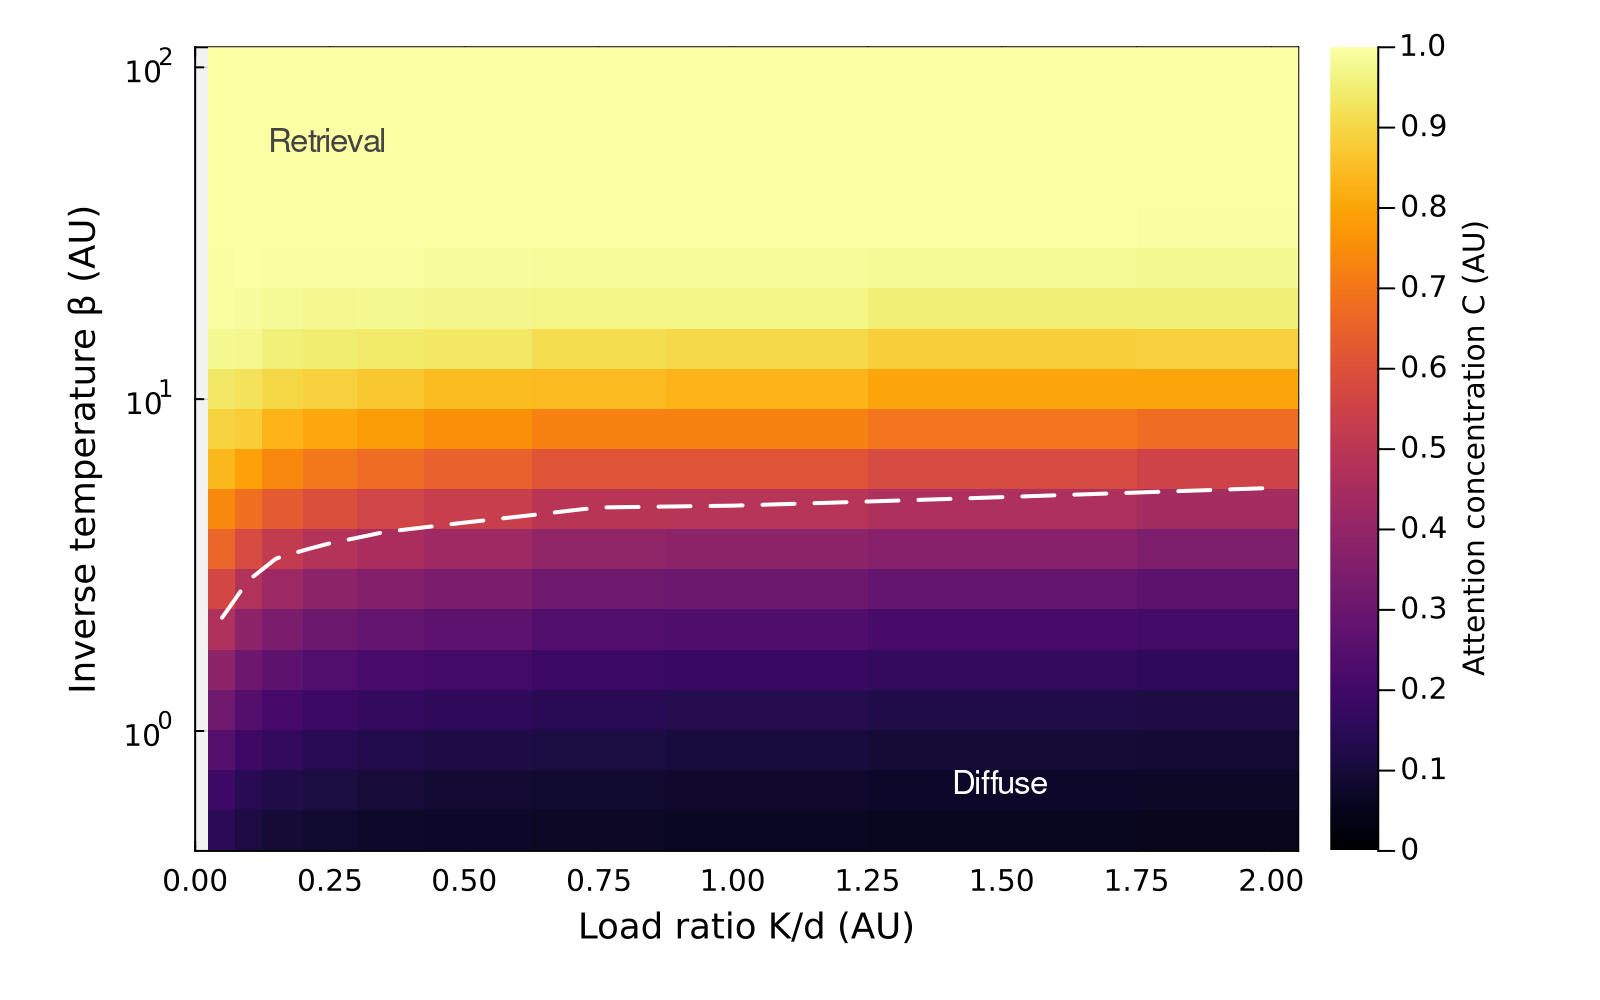

In [14]:
# ── Publication-quality phase diagram heatmap ──
p_phase = heatmap(ratios_plot, βs, C_matrix;
    xlabel    = "Load ratio K/d (AU)",
    ylabel    = "Inverse temperature β (AU)",
    colorbar_title = "Attention concentration C (AU)",
    color     = :inferno,
    clims     = (0, 1),
    xlims     = (0, maximum(ratios_plot) + 0.05),
    xticks    = 0:0.25:maximum(ratios_plot),
    yscale    = :log10,
    size      = (800, 500),
    dpi       = 200,
    guidefontsize  = 12,
    tickfontsize   = 10,
    legendfontsize = 9,
    bg        = "gray95",
    background_color_outside = "white",
    framestyle = :box,
    left_margin   = 10Plots.mm,
    bottom_margin = 8Plots.mm,
    right_margin  = 12Plots.mm,
    top_margin    = 4Plots.mm,
)

# ── Add contour overlay at C = 0.5 (phase boundary) ──
contour!(p_phase, ratios_plot, βs, C_matrix;
    levels    = [0.5],
    linecolor = :white,
    linewidth = 2.0,
    linestyle = :dash,
    colorbar_entry = false,
)

# ── Annotate the two regimes ──
# Use plot font family (not monospace) and dark color for visibility on bright heatmap regions
annotate!(p_phase, 0.25, 60.0, text("Retrieval", 11, :black, :bold, "Helvetica"))
annotate!(p_phase, 1.5, 0.7, text("Diffuse", 11, :white, :bold, "Helvetica"))

# Save to PDF
_PATH_TO_FIGS = joinpath(_ROOT, "figs")
mkpath(_PATH_TO_FIGS)
savefig(p_phase, joinpath(_PATH_TO_FIGS, "Fig_experiment-3-load-ratio.pdf"))
println("Saved: figs/Fig_experiment-3-load-ratio.pdf")

display(p_phase)

___
## Summary
We constructed a phase diagram showing how attention concentration depends jointly on the load ratio K/d and inverse temperature beta.

> __Key Takeaways:__
>
> * **Two-regime structure:** The load-ratio–inverse-temperature plane separates into a retrieval region (high concentration, high inverse temperature, low load ratio) and a disordered region (low concentration, low inverse temperature or high load ratio)
> * **Smooth phase boundary:** The concentration midpoint contour traces a smooth boundary between regimes, indicating a crossover rather than a sharp phase transition
> * **Load ratio controls difficulty:** As the load ratio increases, the retrieval threshold shifts to higher inverse temperature, reflecting the increased interference among stored patterns

___